In [48]:
# load libraires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import triang
from sklearn.neighbors import KernelDensity
import statsmodels.api as sm
from scipy.stats import shapiro

# initial variables and seed
SEED = 112358 # Seed from HW 1
rng  = np.random.default_rng(SEED)

N_SIMS   = 10000
N_YEARS  = 15        # production horizon
WACC     = 0.10      # discount rate

---
## Redo HW 1 stuff



In [49]:
data = pd.read_excel('Analysis_Data_data.xlsx', header=2, sheet_name='Drilling Cost')
data = data[(data['Date'] > '1990-06-30') & (data['Date'] < '2007-06-30')].reset_index(drop=True)

P0 = data.iloc[15, [1, 2, 3]].mean()
print(f"P0 (mean 2006 drilling cost, $1000s): ${P0:,.1f}")

data = pd.melt(
    data,
    id_vars=['Date'],
    value_vars=['Arithmetic Return - Crude Oil',
                'Arithmetic Return - Natural Gas',
                'Arithmetic Return - Dry Well'],
    var_name='Well Type',
    value_name='Change'
)
data = data.sort_values(by=['Date', 'Well Type'], ascending=True).reset_index(drop=True)
data['Well Type'] = data['Well Type'].str.replace('Arithmetic Return - ', '')

rng_hw1 = np.random.default_rng(SEED)
years_hw1 = 6
mu    = data['Change'].mean()
sigma = data['Change'].std()

r_6 = rng_hw1.normal(loc=mu, scale=sigma, size=(N_SIMS, years_hw1))
P6_normal = P0 * np.prod(1 + r_6, axis=1)

sim_12_15 = rng_hw1.uniform(-0.22, -0.07, size=(N_SIMS, 3))
sim_15_25 = rng_hw1.uniform( 0.02,  0.06, size=(N_SIMS, 10))
future_changes = np.concatenate([sim_12_15, sim_15_25], axis=1)

P2025_normal = P6_normal * np.prod(1 + future_changes, axis=1)
print(f"P2025_normal - mean: ${P2025_normal.mean():,.1f}k  |  std: ${P2025_normal.std():,.1f}k")

P0 (mean 2006 drilling cost, $000s): $2,279.8
P2025_normal - mean: $4,417.6k  |  std: $1,809.0k


---
## Well Count Simulation and Plot

In [50]:
n_wells = rng.integers(low=10, high=31, size=N_SIMS) # 31 to include 30

p_produce = 0.85
n_producing = np.array([
    rng.binomial(n=n_wells[i], p=p_produce)
    for i in range(N_SIMS)
])
n_dry = n_wells - n_producing

prop_producing = n_producing / n_wells

print(f"Mean wells per project:    {n_wells.mean():.1f}")
print(f"Mean producing wells:      {n_producing.mean():.1f}")
print(f"Mean dry wells:            {n_dry.mean():.1f}")
print(f"Mean proportion producing: {prop_producing.mean():.3f}")

Mean wells per project:    19.9
Mean producing wells:      17.0
Mean dry wells:            3.0
Mean proportion producing: 0.850


/tmp/ipykernel_16023/333944750.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


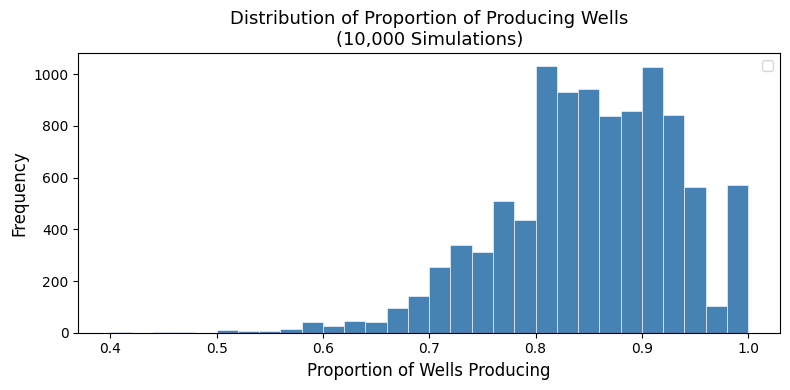

Figure saved.


In [51]:
# Histogram plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prop_producing, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Proportion of Wells Producing', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Proportion of Producing Wells\n(10,000 Simulations)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig_prop_producing.png', dpi=150)
plt.show()
print("Figure saved.")

---
## Oil Price Distributions


In [52]:
# Load price projections
projections = pd.read_excel('Analysis_Data_data.xlsx', header=2, sheet_name='Price Projections')
projections.columns = ['Year', 'High', 'Low', 'Reference']

prod_years = list(range(2026, 2026 + N_YEARS))
price_proj = projections[projections['Year'].isin(prod_years)].reset_index(drop=True)

print(price_proj.to_string(index=False))

 Year       High       Low  Reference
 2026 166.263016 45.745247  85.255096
 2027 167.971329 46.518333  85.532898
 2028 166.407440 47.305279  86.264732
 2029 166.329147 47.445293  86.738144
 2030 167.323944 47.981407  87.188271
 2031 169.405746 48.612011  87.748749
 2032 168.357391 49.241779  88.512123
 2033 170.008057 48.129913  88.937447
 2034 172.798264 47.247337  89.608727
 2035 173.151184 48.183853  90.032150
 2036 172.493591 48.978317  90.825806
 2037 175.043121 48.965652  91.434029
 2038 173.234741 48.364807  91.807198
 2039 174.075836 48.603676  92.341896
 2040 174.940659 47.854874  92.759918


In [53]:
oil_prices = np.zeros((N_SIMS, N_YEARS))

for t, row in price_proj.iterrows():
    lo, hi, mode = row['Low'], row['High'], row['Reference']
    c = (mode - lo) / (hi - lo)
    oil_prices[:, t] = triang.rvs(c=c, loc=lo, scale=(hi - lo),
                                   size=N_SIMS,
                                   random_state=SEED + t)

print(f"Year 1 (2026) - Mean: ${oil_prices[:,0].mean():.2f}  |  Std: ${oil_prices[:,0].std():.2f}")
print(f"Year 15(2040) - Mean: ${oil_prices[:,14].mean():.2f}  |  Std: ${oil_prices[:,14].std():.2f}")

Year 1 (2026) - Mean: $98.82  |  Std: $25.00
Year 15(2040) - Mean: $104.91  |  Std: $26.50


---
## Year 0 stuff


In [54]:
MAX_WELLS = int(n_wells.max())

drill_costs_pool = rng.choice(P2025_normal, size=(N_SIMS, MAX_WELLS), replace=True)  # $1000s
# labeling thousands to ensure consistancy in report

acres_per_well   = rng.normal(600, 50,   size=(N_SIMS, MAX_WELLS))   # acres
sections_per_well= rng.normal(3,   0.35, size=(N_SIMS, MAX_WELLS))   # sections
price_per_acre   = 960          # in $/acre
seismic_per_sec  = 43000       # in $/section

seismic_lease_cost = (acres_per_well * price_per_acre + sections_per_well * seismic_per_sec) / 1000  # $1000s

# triang(172k, 215k, 279.5k)
tri_min, tri_mode, tri_max = 172000, 215000, 279500
tri_c = (tri_mode - tri_min) / (tri_max - tri_min)
overhead_per_well = triang.rvs(
    c=tri_c, loc=tri_min, scale=(tri_max - tri_min),
    size=(N_SIMS, MAX_WELLS),
    random_state=SEED + 999
) / 1000  # $1000s


In [55]:
completion_cost = rng.normal(390000, 50000, size=(N_SIMS, MAX_WELLS)) / 1000  # $1000s

is_producing = np.zeros((N_SIMS, MAX_WELLS), dtype=bool)
is_active    = np.zeros((N_SIMS, MAX_WELLS), dtype=bool)   # all well types dry and not

for i in range(N_SIMS):
    nw = n_wells[i]
    np_ = n_producing[i]
    is_active[i, :nw]   = True
    prod_indices = rng.choice(nw, size=np_, replace=False)
    is_producing[i, prod_indices] = True

print(f"Mean producing per sim: {is_producing.sum(axis=1).mean():.1f}")

Mean producing per sim: 17.0


---
## Production Simulation

In [56]:

rho = 0.64
L = np.array([[1.0,  0.0],
              [rho,  np.sqrt(1 - rho**2)]])

Z = rng.standard_normal(size=(2, N_SIMS * MAX_WELLS))
Z_corr = L @ Z

IP_flat = np.exp(6 + 0.28 * Z_corr[0])  # BOPD

from scipy.stats import norm
u = norm.cdf(Z_corr[1])
DR_flat = 0.15 + u * (0.32 - 0.15)

# Reshape
IP = IP_flat.reshape(N_SIMS, MAX_WELLS)   # BOPD
DR = DR_flat.reshape(N_SIMS, MAX_WELLS)   # fraction

print(f"IP - mean: {IP.mean():.1f} BOPD  |  std: {IP.std():.1f} BOPD")
print(f"DR - mean: {DR.mean():.3f}       |  std: {DR.std():.3f}")
print(f"Corr(IP, DR) check: {np.corrcoef(IP_flat, DR_flat)[0,1]:.4f}  (target 0.64)")

IP - mean: 419.3 BOPD  |  std: 119.5 BOPD
DR - mean: 0.235       |  std: 0.049
Corr(IP, DR) check: 0.6111  (target 0.64)


In [ ]:

t_idx = np.arange(1, N_YEARS + 1)

IP_3d = IP[:, :, np.newaxis]
DR_3d = DR[:, :, np.newaxis]

rate_start = IP_3d * (1 - DR_3d) ** (t_idx - 1)
rate_end   = IP_3d * (1 - DR_3d) ** t_idx
vol_bbl    = 365 * (rate_start + rate_end) / 2      # barrels per well per year

print(f"Mean Year-1 production (per well): {vol_bbl[:,:,0][is_producing].mean():,.0f} bbl")

vol_bbl shape: (10000, 30, 15)
Mean Year-1 production (per well): 134,420 bbl


---
## Revenue Simulation

In [ ]:
NRI = rng.normal(0.75, 0.02, size=(N_SIMS, MAX_WELLS))   # fraction

op_cost_per_bbl = rng.normal(2.25, 0.30, size=(N_SIMS, N_YEARS))  # in $/bbl

sev_tax_rate = 0.046

oil_3d    = oil_prices[:, np.newaxis, :]
NRI_3d    = NRI[:, :, np.newaxis]
op_3d     = op_cost_per_bbl[:, np.newaxis, :]

gross_rev = vol_bbl * oil_3d

net_rev   = gross_rev * NRI_3d

op_exp    = vol_bbl * op_3d

sev_tax   = net_rev * sev_tax_rate

FNR_well  = net_rev - op_exp - sev_tax

FNR_well shape: (10000, 30, 15)


---
## NPV Calculation

In [59]:
discount = 1 / (1 + WACC) ** t_idx   # shape (15,)

is_prod_3d    = is_producing[:, :, np.newaxis]
FNR_producing = FNR_well * is_prod_3d

# PV of revenues in raw dollars ($)
PV_revenues = (FNR_producing * discount).sum(axis=(1, 2))

# are all in $1000s (thousands of dollars), need to multiply by 1,000
is_act_fl = is_active.astype(float)
is_pro_fl = is_producing.astype(float)

total_drilling      = (drill_costs_pool   * is_act_fl).sum(axis=1) * 1000
total_seismic_lease = (seismic_lease_cost * is_act_fl).sum(axis=1) * 1000
total_overhead_yr0  = (overhead_per_well  * is_act_fl).sum(axis=1) * 1000
total_completion    = (completion_cost    * is_pro_fl).sum(axis=1) * 1000   # producers only

total_year0_cost = (total_drilling + total_seismic_lease +
                    total_overhead_yr0 + total_completion)

# overhead_per_well is in $1000s, need multiply by 1,000
overhead_annual_pv = (
    (overhead_per_well * is_pro_fl)[:, :, np.newaxis] * discount
).sum(axis=(1, 2)) * 1000

NPV   = PV_revenues - total_year0_cost - overhead_annual_pv
NPV_M = NPV / 1000000

print(f"NPV stats ($M):")
print(f"  Mean:   ${NPV_M.mean():>10,.2f}M")
print(f"  Median: ${np.median(NPV_M):>10,.2f}M")
print(f"  Std:    ${NPV_M.std():>10,.2f}M")
print(f"  Min:    ${NPV_M.min():>10,.2f}M")
print(f"  Max:    ${NPV_M.max():>10,.2f}M")

NPV stats ($M):
  Mean:   $    327.54M
  Median: $    315.90M
  Std:    $    123.93M
  Min:    $     34.33M
  Max:    $    848.10M


---
## Expected Shortfall

In [60]:
VaR_95 = np.percentile(NPV_M, 5)

ES_95 = NPV_M[NPV_M <= VaR_95].mean()

prob_loss = (NPV_M < 0).mean()

print(f"  Expected NPV (mean):        ${NPV_M.mean():>10,.2f}M")
print(f"  Median NPV:                 ${np.median(NPV_M):>10,.2f}M")
print(f"  Std Dev of NPV:             ${NPV_M.std():>10,.2f}M")
print("---------------------------------------------------------------")
print(f"  VaR (5th pct, 95% conf.):   ${VaR_95:>10,.2f}M")
print(f"  Expected Shortfall (CVaR):  ${ES_95:>10,.2f}M")
print(f"  Probability of Loss:         {prob_loss*100:>9.1f}%")

  Expected NPV (mean):        $    327.54M
  Median NPV:                 $    315.90M
  Std Dev of NPV:             $    123.93M
---------------------------------------------------------------
  VaR (5th pct, 95% conf.):   $    148.23M
  Expected Shortfall (CVaR):  $    122.06M
  Probability of Loss:               0.0%
